In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as sk

from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
df = pd.read_csv('/kaggle/input/datasets/ashydv/housing-dataset/Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [23]:
df.shape

(545, 13)

In [24]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [25]:
df = df.dropna()

In [26]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


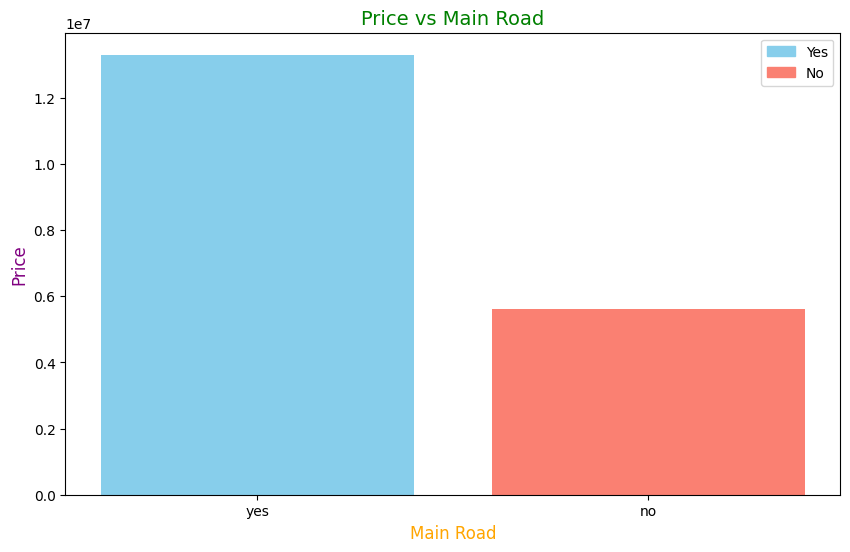

In [27]:
# Assign colors based on mainroad values
import matplotlib.patches as mpatches
colors = df['mainroad'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['mainroad'], df['price'], color=colors)

plt.xlabel('Main Road', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Main Road', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

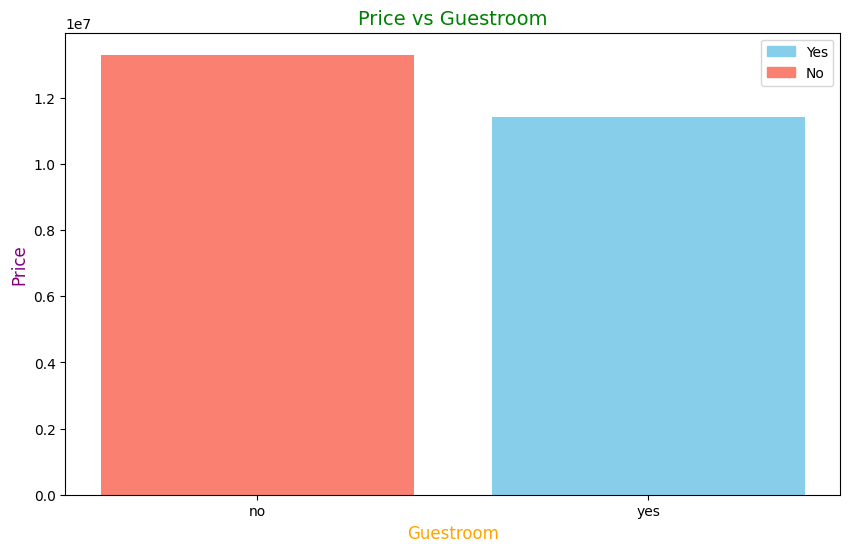

In [28]:
# Assign colors based on guestroom values
import matplotlib.patches as mpatches
colors = df['guestroom'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['guestroom'], df['price'], color=colors)

plt.xlabel('Guestroom', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Guestroom', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

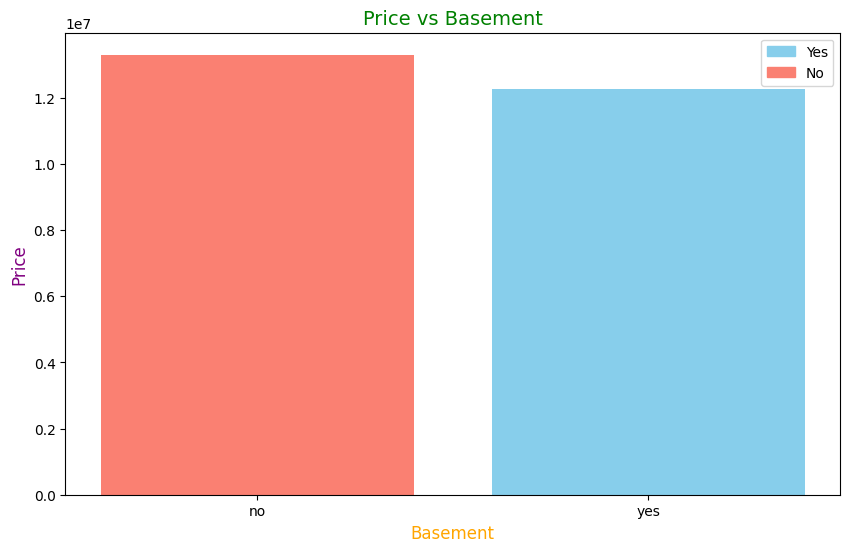

In [29]:
colors = df['basement'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['basement'], df['price'], color=colors)

plt.xlabel('Basement', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Basement', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

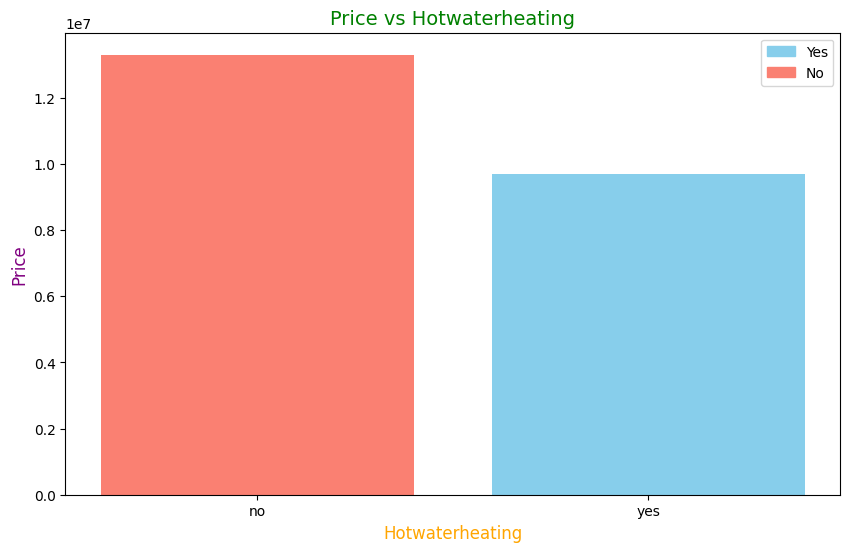

In [30]:
colors = df['hotwaterheating'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['hotwaterheating'], df['price'], color=colors)

plt.xlabel('Hotwaterheating', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Hotwaterheating', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

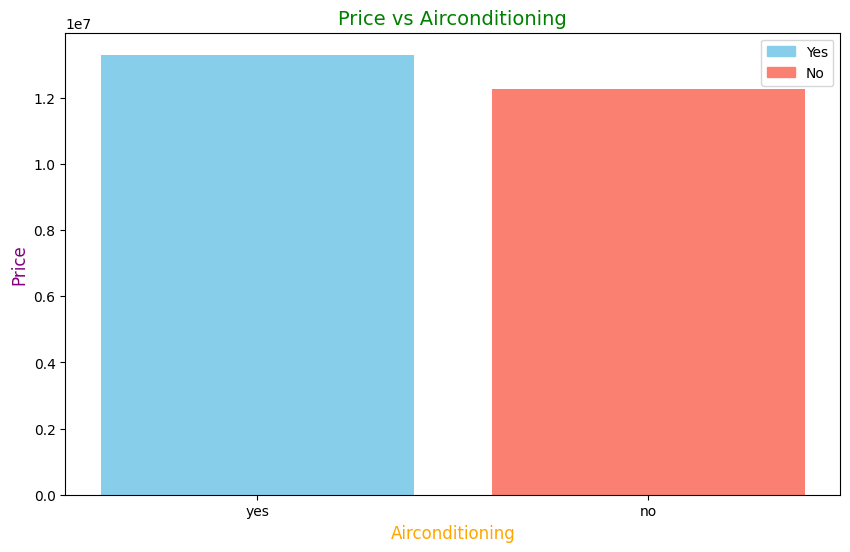

In [31]:
colors = df['airconditioning'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['airconditioning'], df['price'], color=colors)

plt.xlabel('Airconditioning', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Airconditioning', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

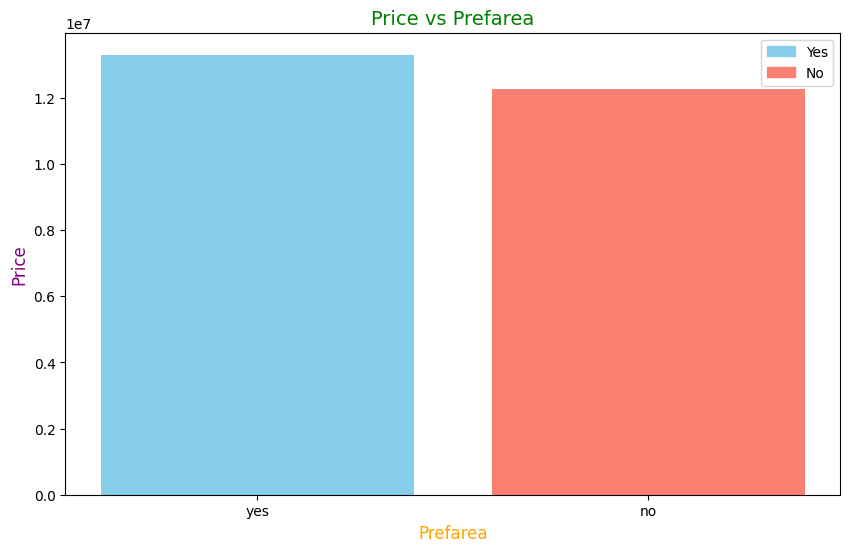

In [32]:
colors = df['prefarea'].map({'yes': 'skyblue', 'no': 'salmon'})

plt.figure(figsize=(10, 6))
plt.bar(df['prefarea'], df['price'], color=colors)

plt.xlabel('Prefarea', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs Prefarea', fontsize=14, color='green')

# Add legend
yes_patch = mpatches.Patch(color='skyblue', label='Yes')
no_patch = mpatches.Patch(color='salmon', label='No')
plt.legend(handles=[yes_patch, no_patch])

plt.show()

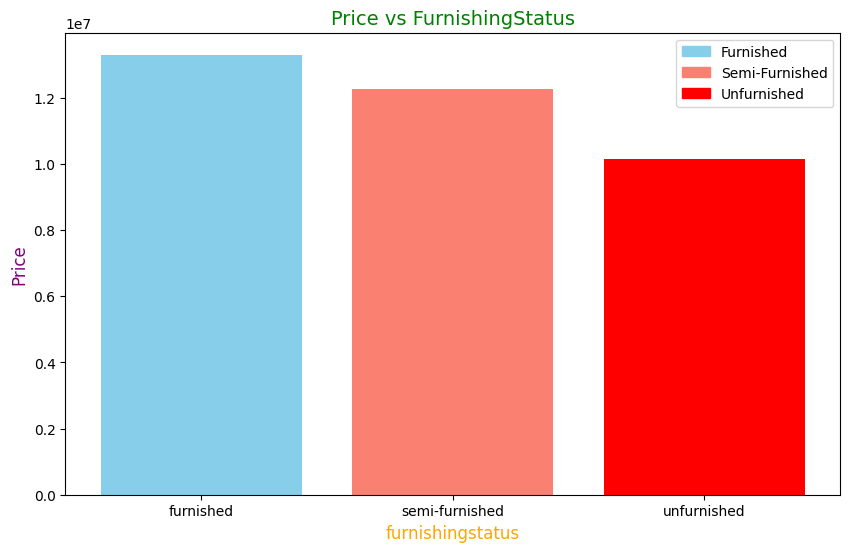

In [33]:
colors = df['furnishingstatus'].map({
    'furnished': 'skyblue',
    'semi-furnished': 'salmon',
    'unfurnished': 'red'
})

plt.figure(figsize=(10, 6))
plt.bar(df['furnishingstatus'], df['price'], color=colors)

plt.xlabel('furnishingstatus', fontsize=12, color='orange')
plt.ylabel('Price', fontsize=12, color='purple')
plt.title('Price vs FurnishingStatus', fontsize=14, color='green')

# Define patches for legend
furnished_patch = mpatches.Patch(color='skyblue', label='Furnished')
semi_furnished_patch = mpatches.Patch(color='salmon', label='Semi-Furnished')
unfurnished_patch = mpatches.Patch(color='red', label='Unfurnished')

# Add legend
plt.legend(handles=[furnished_patch, semi_furnished_patch, unfurnished_patch])

# Example usage in a plot (optional)
plt.show()

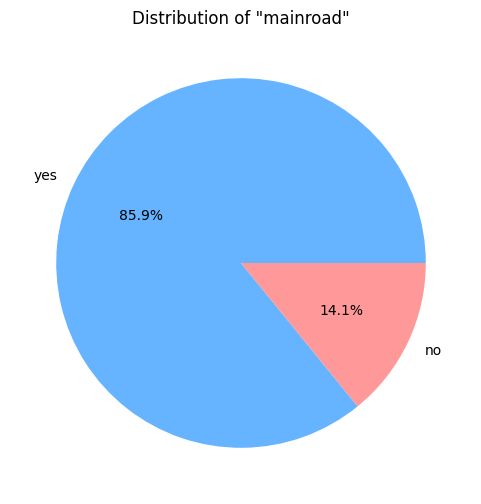

In [34]:
# Get the value counts for the selected column
value_counts = df['mainroad'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Distribution of "mainroad"')
plt.show()

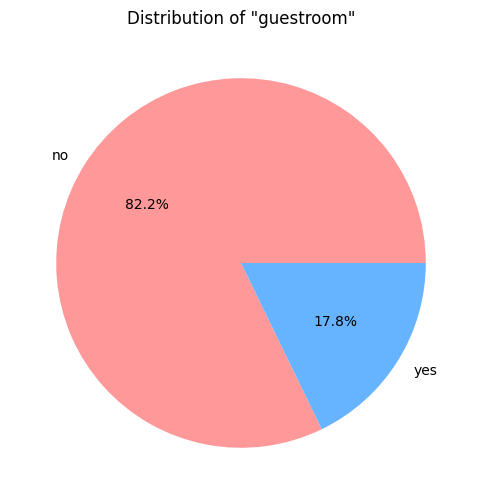

In [35]:
# Get the value counts for the selected column
value_counts = df['guestroom'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Distribution of "guestroom"')
plt.show()

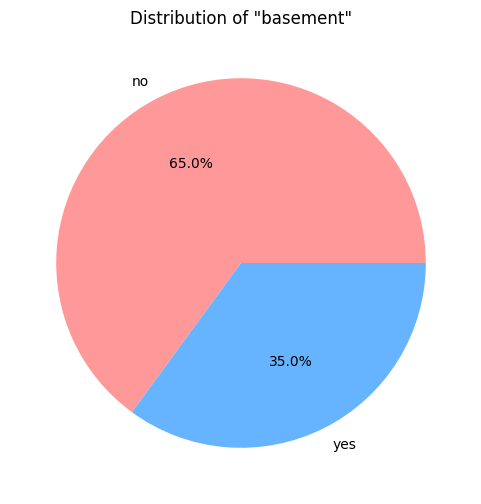

In [36]:
# Get the value counts for the selected column
value_counts = df['basement'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Distribution of "basement"')
plt.show()

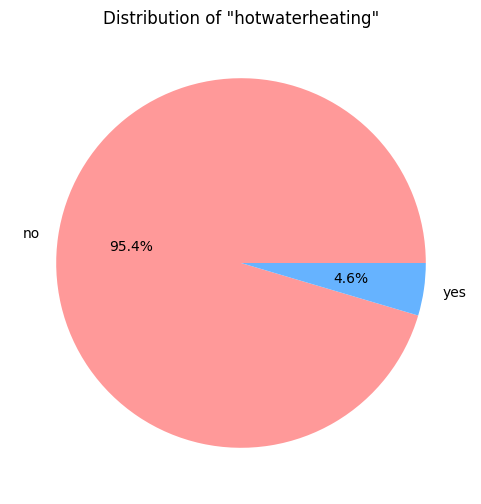

In [37]:
# Get the value counts for the selected column
value_counts = df['hotwaterheating'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Distribution of "hotwaterheating"')
plt.show()

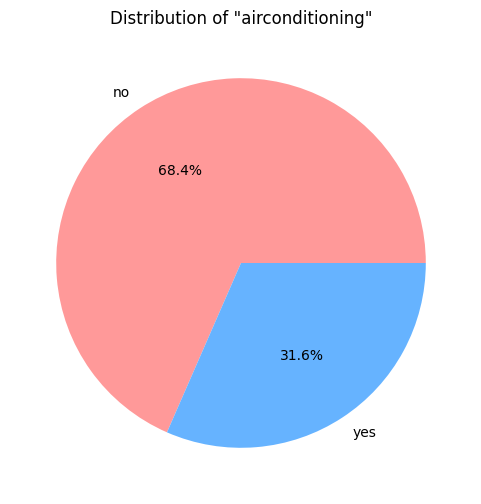

In [38]:
# Get the value counts for the selected column
value_counts = df['airconditioning'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Distribution of "airconditioning"')
plt.show()

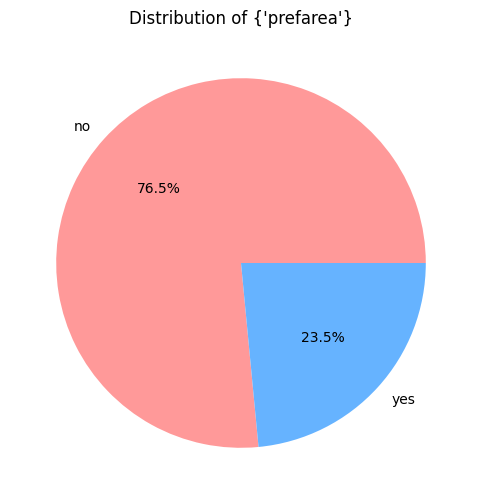

In [40]:
# Get the value counts for the selected column
value_counts = df['prefarea'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title("Distribution of {'prefarea'}")
plt.show()

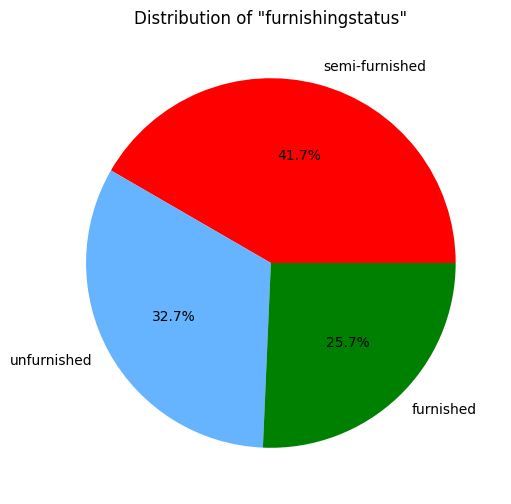

In [41]:
# Get the value counts for the selected column
value_counts = df['furnishingstatus'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['red', '#66b3ff', 'green'])
plt.title('Distribution of "furnishingstatus"')
plt.show()

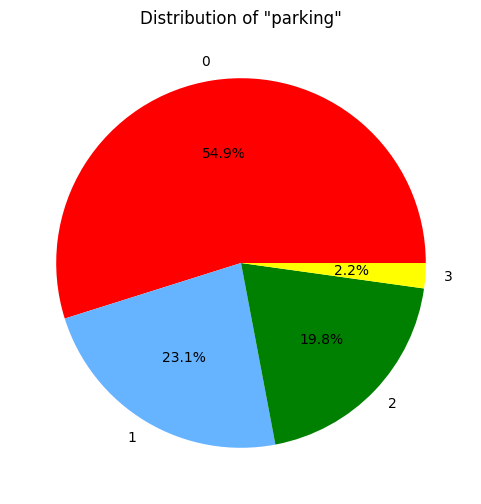

In [42]:
# Get the value counts for the selected column
value_counts = df['parking'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=['red', '#66b3ff', 'green', 'yellow'])
plt.title('Distribution of "parking"')
plt.show()

In [45]:
# Selecting relevant features (Assuming dataset contains these columns)
features = ['area', 'bedrooms', 'bathrooms', 'stories']
target = 'price'

In [46]:
# Selecting relevant features (Assuming dataset contains these columns)
features = ['area', 'bedrooms', 'bathrooms', 'stories']
target = 'price'

X = df[features]
y = df[target]

In [47]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [56]:
# Predictions
y_pred = model.predict(X_test)

In [57]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [58]:
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

MAE: 1158970.480316688
MSE: 2457741642022.09
RMSE: 1567718.610600158
R2 Score: 0.5137585349037066


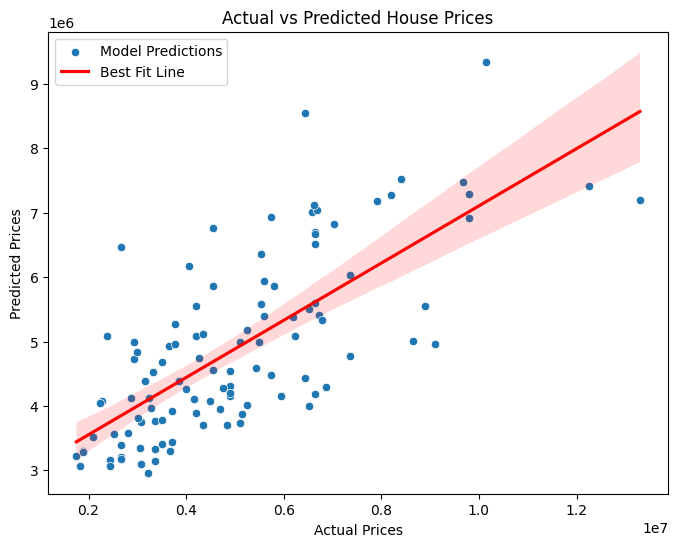

In [59]:
# Scatter plot visualization with Line of Best Fit
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, label="Model Predictions")
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red', label="Best Fit Line")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

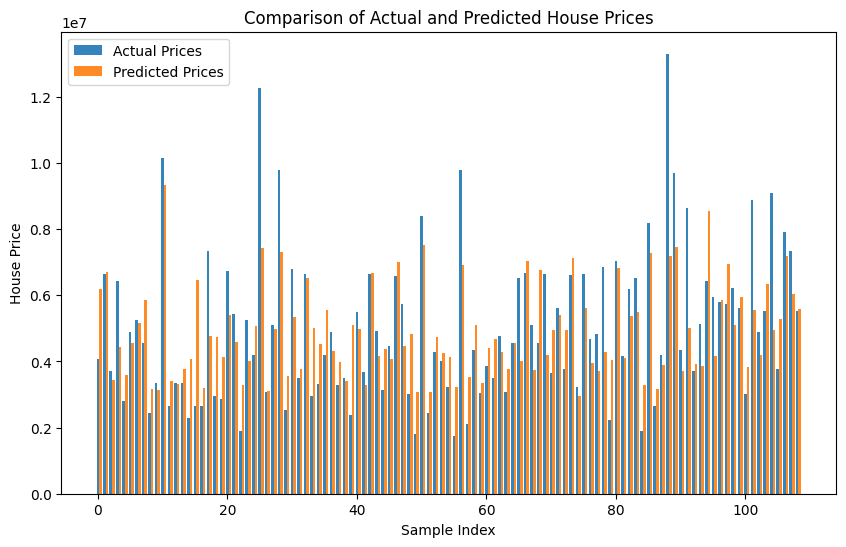

In [60]:
# Bar graph visualization
plt.figure(figsize=(10, 6))

indices = np.arange(len(y_test))
plt.bar(indices, y_test.values, width=0.4, label="Actual Prices", alpha=0.9)
plt.bar(indices + 0.4, y_pred, width=0.4, label="Predicted Prices", alpha=0.9)

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Comparison of Actual and Predicted House Prices")

plt.legend()
plt.show()